# Benchmark: Serial vs Parallel Iterative SLSQP

Compares the current serial `iterative_with_jacobians2` implementation against
the parallelized `iterative_parallel` which batches non-overlapping windows
into a `ProcessPoolExecutor`.

In [1]:
import time
import numpy as np
import modules.laplacian as laplacian
from modules.dvfopt import iterative_with_jacobians2, jacobian_det2D, iterative_parallel
from modules.dvfviz import plot_deformations, plot_initial_deformation

## Helper: benchmark runner

In [2]:
def benchmark(deformation_i, label, msample=None, fsample=None, n_runs=1, **kwargs):
    """Run serial and parallel, print comparison table."""
    print(f"\n{'='*70}")
    print(f"  BENCHMARK: {label}")
    print(f"  Grid: {deformation_i.shape[-2]}x{deformation_i.shape[-1]}")
    jac_init = jacobian_det2D(np.stack([deformation_i[-2], deformation_i[-1]]))
    n_neg = int((jac_init <= 0).sum())
    print(f"  Initial neg-Jdet pixels: {n_neg}")
    print(f"{'='*70}\n")

    results = {}

    for name, func in [("Serial", iterative_with_jacobians2),
                        ("Parallel", iterative_parallel)]:
        times = []
        for run in range(n_runs):
            t0 = time.perf_counter()
            phi = func(deformation_i.copy(), verbose=0, **kwargs)
            elapsed = time.perf_counter() - t0
            times.append(elapsed)

        jac_final = jacobian_det2D(phi)
        final_neg = int((jac_final <= 0).sum())
        final_min = float(jac_final.min())
        l2_err = float(np.sqrt(np.sum((phi - np.stack([deformation_i[-2, 0], deformation_i[-1, 0]]))**2)))

        avg_t = np.mean(times)
        std_t = np.std(times) if n_runs > 1 else 0.0

        results[name] = {
            "time_avg": avg_t,
            "time_std": std_t,
            "times": times,
            "final_neg": final_neg,
            "final_min": final_min,
            "l2_err": l2_err,
            "phi": phi,
        }

        print(f"  {name:10s}:  {avg_t:8.2f}s (±{std_t:.2f}s)  |  "
              f"neg_jdet={final_neg}  min_jdet={final_min:+.6f}  L2={l2_err:.4f}")

    # Speedup
    if results["Serial"]["time_avg"] > 0:
        speedup = results["Serial"]["time_avg"] / results["Parallel"]["time_avg"]
        print(f"\n  Speedup: {speedup:.2f}x")

    print()
    return results

---
## Test Case 1: 20×40 grid, 8 correspondences (from notebook)

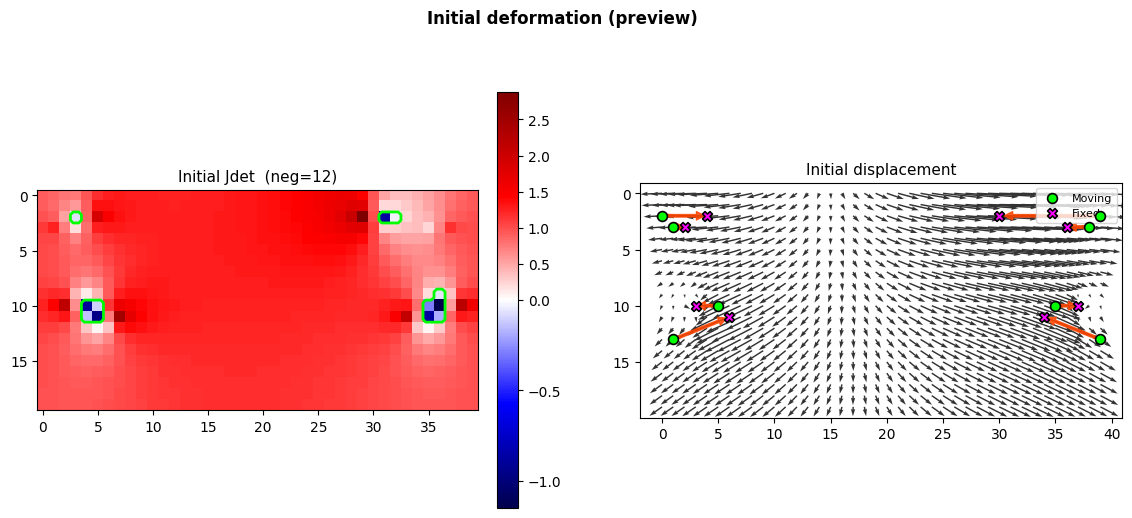


  BENCHMARK: 20x40, 8 correspondences
  Grid: 20x40
  Initial neg-Jdet pixels: 12

  Serial    :      0.77s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=2.0251
  Parallel  :      0.95s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=2.0251

  Speedup: 0.82x



In [3]:
msample = np.array([
    [0, 2, 0],
    [0, 3, 1],
    [0, 10, 5],
    [0, 13, 1],
    [0, 2, 39],
    [0, 3, 38],
    [0, 10, 35],
    [0, 13, 39],
])
fsample = np.array([
    [0, 2, 4],
    [0, 3, 2],
    [0, 10, 3],
    [0, 11, 6],
    [0, 2, 30],
    [0, 3, 36],
    [0, 10, 37],
    [0, 11, 34]
])

fixed_sample = np.zeros((1, 20, 40))
deformation_i, *_ = laplacian.sliceToSlice3DLaplacian(fixed_sample, msample, fsample)
plot_initial_deformation(deformation_i, msample, fsample)

r1 = benchmark(deformation_i, "20x40, 8 correspondences")

## Test Case 2: 10×10 crossing

In [4]:
msample = np.array([
    [0, 2, 2],
    [0, 3, 5],
])
fsample = np.array([
    [0, 2, 5],
    [0, 3, 2],
])

fixed_sample = np.zeros((1, 10, 10))
deformation_i, *_ = laplacian.sliceToSlice3DLaplacian(fixed_sample, msample, fsample)

r2 = benchmark(deformation_i, "10x10, 2 crossing")


  BENCHMARK: 10x10, 2 crossing
  Grid: 10x10
  Initial neg-Jdet pixels: 4

  Serial    :      0.11s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=1.1844
  Parallel  :      0.10s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=1.1844

  Speedup: 1.09x



## Test Case 3: 20×40, 20 correspondences (dense)

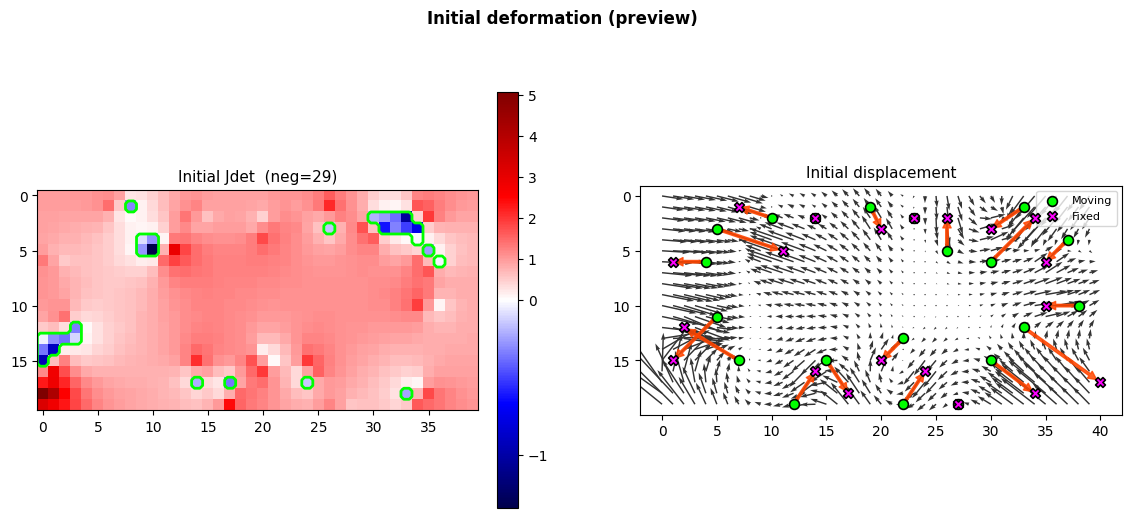


  BENCHMARK: 20x40, 20 correspondences
  Grid: 20x40
  Initial neg-Jdet pixels: 29

  Serial    :      5.65s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=2.9595
  Parallel  :      1.30s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=2.9527

  Speedup: 4.36x



In [5]:
msample = np.array([
    [0, 2, 10],
    [0, 3, 5],
    [0, 6, 4],
    [0, 11, 5],
    [0, 15, 7],
    [0, 19, 12],
    [0, 15, 15],
    [0, 13, 22],
    [0, 19, 22],
    [0, 19, 27],
    [0, 15, 30],
    [0, 12, 33],
    [0, 10, 38],
    [0, 4, 37],
    [0, 6, 30],
    [0, 1, 33],
    [0, 5, 26],
    [0, 2, 23],
    [0, 1, 19],
    [0, 2, 14],
])
fsample = np.array([
    [0, 1, 7],
    [0, 5, 11],
    [0, 6, 1],
    [0, 15, 1],
    [0, 12, 2],
    [0, 16, 14],
    [0, 18, 17],
    [0, 15, 20],
    [0, 16, 24],
    [0, 19, 27],
    [0, 18, 34],
    [0, 17, 40],
    [0, 10, 35],
    [0, 6, 35],
    [0, 2, 34],
    [0, 3, 30],
    [0, 2, 26],
    [0, 2, 23],
    [0, 3, 20],
    [0, 2, 14],
])

fixed_sample = np.zeros((1, 20, 40))
deformation_i, *_ = laplacian.sliceToSlice3DLaplacian(fixed_sample, msample, fsample)
plot_initial_deformation(deformation_i, msample, fsample)

r3 = benchmark(deformation_i, "20x40, 20 correspondences")

## Test Case 3b: 320×456, 20 correspondences (large, scattered neg-Jdet spots)

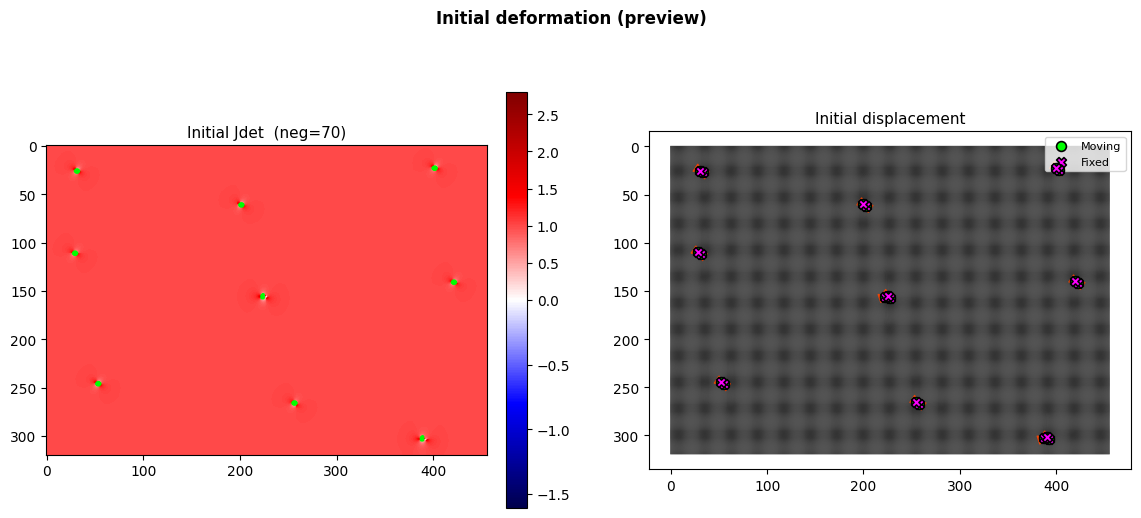


  BENCHMARK: 320x456, 20 correspondences
  Grid: 320x456
  Initial neg-Jdet pixels: 70

  Serial    :      1.53s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=4.8157
  Parallel  :      1.21s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=4.8157

  Speedup: 1.26x



In [6]:
# 320x456 grid with ~20 correspondences scattered around the image.
# Pairs are tightly spaced (2-5 px apart) so each cluster produces a
# small, localised negative-Jdet spot rather than a broad region.

msample = np.array([
    # top-left cluster
    [0,  25,  30],
    [0,  27,  33],
    # top-right cluster
    [0,  22, 400],
    [0,  24, 403],
    # upper-middle — crossing pair
    [0,  60, 200],
    [0,  62, 203],
    # left side
    [0, 110,  28],
    [0, 112,  31],
    # centre cluster
    [0, 155, 225],
    [0, 157, 228],
    [0, 156, 222],
    # right side
    [0, 140, 420],
    [0, 142, 423],
    # lower-left
    [0, 245,  52],
    [0, 247,  55],
    # lower-centre
    [0, 265, 255],
    [0, 267, 258],
    # bottom-right cluster
    [0, 302, 390],
    [0, 304, 393],
    [0, 303, 387],
])

fsample = np.array([
    # top-left cluster — swap
    [0,  27,  33],
    [0,  25,  30],
    # top-right cluster — swap
    [0,  24, 403],
    [0,  22, 400],
    # upper-middle — swap
    [0,  62, 203],
    [0,  60, 200],
    # left side — swap
    [0, 112,  31],
    [0, 110,  28],
    # centre cluster — 3-way crossing
    [0, 157, 228],
    [0, 156, 222],
    [0, 155, 225],
    # right side — swap
    [0, 142, 423],
    [0, 140, 420],
    # lower-left — swap
    [0, 247,  55],
    [0, 245,  52],
    # lower-centre — swap
    [0, 267, 258],
    [0, 265, 255],
    # bottom-right cluster — 3-way crossing
    [0, 304, 393],
    [0, 303, 387],
    [0, 302, 390],
])

fixed_sample = np.zeros((1, 320, 456))
deformation_i, *_ = laplacian.sliceToSlice3DLaplacian(fixed_sample, msample, fsample)
plot_initial_deformation(deformation_i, msample, fsample)

r3b = benchmark(deformation_i, "320x456, 20 correspondences")

## Test Case 4: Real data — 64×91 slice

In [7]:
import os

real_path = "experiments/02b_64x91_slice200.npy"
if os.path.exists(real_path):
    deformation_i = np.load(real_path)
    plot_initial_deformation(deformation_i)
    r4 = benchmark(deformation_i, "64x91 real slice 200")
else:
    print(f"Skipping — {real_path} not found")

Skipping — experiments/02b_64x91_slice200.npy not found


## Test Case 5: Saved .npy test cases

In [8]:
npy_cases = [
    ("experiments/03a_10x10_opposite.npy", "10x10 opposites"),
    ("experiments/03b_10x10_crossing.npy", "10x10 crossing"),
    ("experiments/03c_20x20_opposite.npy", "20x20 opposites"),
    ("experiments/03d_20x20_crossing.npy", "20x20 crossing"),
]

npy_results = {}
for path, label in npy_cases:
    if os.path.exists(path):
        deformation_i = np.load(path)
        npy_results[label] = benchmark(deformation_i, label)
    else:
        print(f"Skipping — {path} not found")

Skipping — experiments/03a_10x10_opposite.npy not found
Skipping — experiments/03b_10x10_crossing.npy not found
Skipping — experiments/03c_20x20_opposite.npy not found
Skipping — experiments/03d_20x20_crossing.npy not found


---
## Summary table

In [9]:
all_results = {}
for name, r in [("20x40 (8 corr)", r1),
                ("10x10 crossing", r2),
                ("20x40 (20 corr)", r3),
                ("320x456 (20 corr)", r3b)]:
    all_results[name] = r

if 'r4' in dir():
    all_results["64x91 real"] = r4

for name, r in npy_results.items():
    all_results[name] = r

print(f"{'Test Case':<22s}  {'Serial (s)':>12s}  {'Parallel (s)':>14s}  {'Speedup':>8s}  {'S neg':>6s}  {'P neg':>6s}  {'S L2':>10s}  {'P L2':>10s}")
print("-" * 110)
for label, r in all_results.items():
    s = r["Serial"]
    p = r["Parallel"]
    speedup = s["time_avg"] / p["time_avg"] if p["time_avg"] > 0 else float('inf')
    print(f"{label:<22s}  {s['time_avg']:12.2f}  {p['time_avg']:14.2f}  {speedup:7.2f}x  "
          f"{s['final_neg']:6d}  {p['final_neg']:6d}  {s['l2_err']:10.4f}  {p['l2_err']:10.4f}")

# Summary stats
print()
print("=" * 110)
speedups = {}
for label, r in all_results.items():
    s_t = r["Serial"]["time_avg"]
    p_t = r["Parallel"]["time_avg"]
    speedups[label] = s_t / p_t if p_t > 0 else float('inf')

best_label = max(speedups, key=speedups.get)
worst_label = min(speedups, key=speedups.get)

total_serial = sum(r["Serial"]["time_avg"] for r in all_results.values())
total_parallel = sum(r["Parallel"]["time_avg"] for r in all_results.values())
overall_speedup = total_serial / total_parallel if total_parallel > 0 else float('inf')

# Check correctness: all parallel runs should have 0 remaining neg-Jdet
all_correct = all(r["Parallel"]["final_neg"] == 0 for r in all_results.values())

print(f"  Best speedup  : {speedups[best_label]:.2f}x  ({best_label})")
print(f"  Worst speedup : {speedups[worst_label]:.2f}x  ({worst_label})")
print(f"  Overall       : {overall_speedup:.2f}x  (total {total_serial:.1f}s serial → {total_parallel:.1f}s parallel)")
print(f"  Correctness   : {'All parallel runs reached 0 neg-Jdet' if all_correct else 'WARNING: some parallel runs have remaining neg-Jdet!'}")
print("=" * 110)

Test Case                 Serial (s)    Parallel (s)   Speedup   S neg   P neg        S L2        P L2
--------------------------------------------------------------------------------------------------------------
20x40 (8 corr)                  0.77            0.95     0.82x       0       0      2.0251      2.0251
10x10 crossing                  0.11            0.10     1.09x       0       0      1.1844      1.1844
20x40 (20 corr)                 5.65            1.30     4.36x       0       0      2.9595      2.9527
320x456 (20 corr)               1.53            1.21     1.26x       0       0      4.8157      4.8157

  Best speedup  : 4.36x  (20x40 (20 corr))
  Worst speedup : 0.82x  (20x40 (8 corr))
  Overall       : 2.27x  (total 8.1s serial → 3.6s parallel)
  Correctness   : All parallel runs reached 0 neg-Jdet


## Visual comparison (last test case)

In [10]:
# Pick the last available results to visualise
last_label = list(all_results.keys())[-1]
last_r = all_results[last_label]

# Reload the deformation for the last case to show side-by-side
print(f"Visual comparison for: {last_label}")
print(f"\nSerial result:")
print(f"  neg_jdet={last_r['Serial']['final_neg']}  min_jdet={last_r['Serial']['final_min']:+.6f}  L2={last_r['Serial']['l2_err']:.4f}")
print(f"\nParallel result:")
print(f"  neg_jdet={last_r['Parallel']['final_neg']}  min_jdet={last_r['Parallel']['final_min']:+.6f}  L2={last_r['Parallel']['l2_err']:.4f}")

# Difference between serial and parallel phi
diff = np.abs(last_r['Serial']['phi'] - last_r['Parallel']['phi'])
print(f"\nMax |phi_serial - phi_parallel|: {diff.max():.6f}")
print(f"Mean |phi_serial - phi_parallel|: {diff.mean():.6f}")

Visual comparison for: 320x456 (20 corr)

Serial result:
  neg_jdet=0  min_jdet=+0.010000  L2=4.8157

Parallel result:
  neg_jdet=0  min_jdet=+0.010000  L2=4.8157

Max |phi_serial - phi_parallel|: 0.000000
Mean |phi_serial - phi_parallel|: 0.000000
